# Module 2: Using Google Colab to Run R Analyses of HINTS 7 Data and Answer Your Chosen Research Question
**Last updated:** 2025-09-12

**Goal:** Run the code to install and load required R packages, load the HINTS7 dataset, perform basic data cleaning, and answer your chosen research question.

**Before you start:**
1. **Runtime → Change runtime type → Language = R** → Save.
2. **File → Save a copy in Drive** so you have your own copy.

In [1]:
# @title Install & load required packages
opts <- getOption('repos'); opts['CRAN'] <- 'https://cloud.r-project.org'; options(repos = opts)
to_install <- c('dplyr','readr','ggplot2','tidyverse','gtsummary','MASS','tableone','scales')
installed <- rownames(installed.packages())
need <- setdiff(to_install, installed)
if (length(need)) install.packages(need)
invisible(lapply(to_install, require, character.only = TRUE))
set.seed(2025)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘V8’, ‘litedown’, ‘reactR’, ‘gtools’, ‘bigD’, ‘bitops’, ‘juicyjuice’, ‘markdown’, ‘reactable’, ‘minqa’, ‘numDeriv’, ‘mitools’, ‘RcppArmadillo’, ‘proxy’, ‘gdata’, ‘cards’, ‘cardx’, ‘gt’, ‘survey’, ‘e1071’, ‘zoo’, ‘gmodels’, ‘labelled’


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: readr

Loading required package: ggplot2

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks st

## Load HINTS 7 (public Google Drive link)
This notebook uses your public Drive file. If it ever rate-limits, see the manual upload fallback cell.

In [2]:
# Robust loader: tries RDA/RDS/TSV/CSV in that order
file_id <- '1_rlxyS1RerGPXmpIwIA0jYrMFVbtUEbo'
hints_url <- sprintf('https://drive.google.com/uc?export=download&id=%s', file_id)
tmp <- tempfile()
download.file(hints_url, tmp, mode = 'wb', quiet = TRUE)

# Try .rda
public <- NULL
try({ e <- new.env(); load(tmp, envir = e); if (exists('public', envir = e)) public <- get('public', envir = e)
  else { for (nm in ls(e)) { obj <- get(nm, envir = e); if (is.data.frame(obj)) { public <- obj; break } } } }, silent=TRUE)
# Try .rds
if (is.null(public)) { try({ public <- readRDS(tmp) }, silent=TRUE) }
# Try .tsv
if (is.null(public)) { try({ public <- readr::read_tsv(tmp, show_col_types = FALSE) }, silent=TRUE) }
# Try .csv
if (is.null(public)) { try({ public <- readr::read_csv(tmp, show_col_types = FALSE) }, silent=TRUE) }
stopifnot(!is.null(public))
hints_df <- public; rm(public)
cat('Loaded HINTS with', nrow(hints_df), 'rows and', ncol(hints_df), 'columns\n')
print(names(hints_df)[1:min(50, ncol(hints_df))])


Warning message:
“file ‘filea37dcc65a9’ has magic number 'HHID	'
  Use of save versions prior to 2 is deprecated”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


Loaded HINTS with 7279 rows and 470 columns
 [1] "HHID"                     "APP_REGION"              
 [3] "DRA"                      "RUC2003"                 
 [5] "RUC2013"                  "RUC2023"                 
 [7] "PR_RUCA_2010"             "NCHSURCODE2013"          
 [9] "CENSDIV"                  "CENSREG"                 
[11] "STRATUM"                  "VAR_STRATUM"             
[13] "VAR_CLUSTER"              "FormType"                
[15] "Language_Flag"            "NR_FUFLG"                
[17] "Treatment_H7_1"           "Treatment_H7_2"          
[19] "Updatedate"               "AdultsinHH"              
[21] "MailHHAdults"             "CommitmentStmt"          
[23] "SeekCancerInfo"           "CancerLotOfEffort"       
[25] "CancerFrustrated"         "CancerConcernedQuality"  
[27] "CancerTooHardUnderstand"  "CancerTrustDoctor"       
[29] "CancerTrustFamily"        "CancerTrustGov"          
[31] "CancerTrustCharities"     "CancerTrustReligiousOrgs"
[33] "Cancer

## Data cleaning
This section involves some basic data cleaning steps. We select 4 relevant columns: HHID, age, sex, and race. We then remove unwanted values for these variables. Finally, we compute some descriptive analyses.

In [4]:
# Select the relevant columns
subset_data <- hints_df[, c('HHID','Age','BirthSex','Race_Cat2')]
# View the new dataset
head(subset_data)


HHID,Age,BirthSex,Race_Cat2
<dbl>,<dbl>,<chr>,<chr>
72100001,69,Male,White only
72100005,62,Female,White only
72100014,34,Female,White only
72100019,65,Male,White only
72100025,64,Female,White only
72100026,64,Male,Multiple races selected


In [5]:
# Clean the negative value for age
subset_data <- subset_data %>% dplyr::filter(Age >= 0)
summary(subset_data$Age)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  18.00   41.00   58.00   55.69   70.00  102.00 

In [6]:
# Print unique values for BirthSex
unique(subset_data$BirthSex)


[1] "Male"                           "Female"                        
[3] "Dont know"                      "Missing data (Not Ascertained)"

In [7]:
# Keep only rows where BirthSex is NOT 'Dont know' or 'Missing data (Not Ascertained)'
subset_data <- subset_data[!subset_data$BirthSex %in% c('Dont know','Missing data (Not Ascertained)'), ]
unique(subset_data$BirthSex)


[1] "Male"   "Female"

In [8]:
# Unique values for Race_Cat2
unique(subset_data$Race_Cat2)


[1] "White only"                                      
 [2] "Multiple races selected"                         
 [3] "Black only"                                      
 [4] "Filipino only"                                   
 [5] "Chinese only"                                    
 [6] "Asian Indian only"                               
 [7] "Missing data (Not Ascertained)"                  
 [8] "Japanese only"                                   
 [9] "Other Asian only"                                
[10] "Vietnamese only"                                 
[11] "Korean only"                                     
[12] "Other Pacific Islander only"                     
[13] "American Indian or Alaska Native only"           
[14] "Missing data (Web partial - Question Never Seen)"

In [9]:
# Filter out unwanted Race_Cat2 values, then rename to Race
subset_data <- subset_data[!subset_data$Race_Cat2 %in% c('Missing data (Not Ascertained)',
                                                        'Missing data (Web partial - Question Never Seen)'), ]
names(subset_data)[names(subset_data) == 'Race_Cat2'] <- 'Race'
unique(subset_data$Race)


[1] "White only"                           
 [2] "Multiple races selected"              
 [3] "Black only"                           
 [4] "Filipino only"                        
 [5] "Chinese only"                         
 [6] "Asian Indian only"                    
 [7] "Japanese only"                        
 [8] "Other Asian only"                     
 [9] "Vietnamese only"                      
[10] "Korean only"                          
[11] "Other Pacific Islander only"          
[12] "American Indian or Alaska Native only"

In [10]:
# Description Analysis
mean_age <- mean(subset_data$Age, na.rm = TRUE)
sex_counts <- table(subset_data$BirthSex)
race_counts <- table(subset_data$Race)
cat('Mean Age:\n'); print(mean_age)
cat('\nCounts by BirthSex:\n'); print(sex_counts)
cat('\nCounts by Race:\n'); print(race_counts)


Mean Age:
[1] 55.88866

Counts by BirthSex:

Female   Male 
  3835   2533 

Counts by Race:

American Indian or Alaska Native only                     Asian Indian only 
                                   53                                    78 
                           Black only                          Chinese only 
                                 1117                                    95 
                        Filipino only                         Japanese only 
                                   55                                    17 
                          Korean only               Multiple races selected 
                                   35                                   299 
                     Other Asian only           Other Pacific Islander only 
                                   41                                    56 
                      Vietnamese only                            White only 
                                   37                       

---
# Research Questions


Please pick one research question (1, 2, or 3) below and run the code for it. What can you interpret from the output?

## Research Question 1
**Does the use of wearable health technology correlate with frequency of healthcare visits or care coordination quality?**

In [11]:
# Select variables
hints7_filtered <- hints_df %>%
  dplyr::select(HHID, WearableDevTrackHealth2, FreqGoProvider, ManageMultipleProviders,
                Age, BirthSex, RaceEthn, IncomeRanges, EducB)

# Clean unwanted labels and Age
bad_labels <- c('Missing data (Not Ascertained)','Missing Data (Not Ascertained)',
                'Missing data (Web partial - Question Never Seen)','Missing Data (Web partial - Question Never Seen)',
                'Dont know','Multiple responses selected in error','Unreadable or Nonconforming Numeric Response')
hints7_cleaned <- hints7_filtered %>%
  mutate(across(everything(), as.character)) %>%
  filter(if_all(everything(), ~ !. %in% bad_labels)) %>%
  mutate(Age = as.numeric(Age)) %>%
  filter(Age >= 0)
summary(hints7_cleaned)


     HHID           WearableDevTrackHealth2 FreqGoProvider    
 Length:5958        Length:5958             Length:5958       
 Class :character   Class :character        Class :character  
 Mode  :character   Mode  :character        Mode  :character  
                                                              
                                                              
                                                              
 ManageMultipleProviders      Age           BirthSex           RaceEthn        
 Length:5958             Min.   : 18.00   Length:5958        Length:5958       
 Class :character        1st Qu.: 40.00   Class :character   Class :character  
 Mode  :character        Median : 57.00   Mode  :character   Mode  :character  
                         Mean   : 54.57                                        
                         3rd Qu.: 69.00                                        
                         Max.   :102.00                                        

In [12]:
vars <- c('Age','BirthSex','RaceEthn','IncomeRanges','EducB')
table1 <- tableone::CreateTableOne(vars = vars, data = hints7_cleaned)
print(table1, showAllLevels = TRUE)


                  
                   level                                                 
  n                                                                      
  Age (mean (SD))                                                        
  BirthSex (%)     Female                                                
                   Male                                                  
  RaceEthn (%)     Hispanic                                              
                   Non-Hispanic American Indian or Alaska Native         
                   Non-Hispanic Asian                                    
                   Non-Hispanic Black or African American                
                   Non-Hispanic Multiple Races Mentioned                 
                   Non-Hispanic Native Hawaiian or other Pacific Islander
                   Non-Hispanic White                                    
  IncomeRanges (%) $0 to $9,999                                          
                   

In [13]:
# Prepare factors and model variables
hints7_cleaned <- hints7_cleaned %>% mutate(
  WearableUse = factor(WearableDevTrackHealth2),
  FreqGoProvider = factor(FreqGoProvider, levels = c('None','1 time','2 times','3 times','4 times','5-9 times','10 or more times'), ordered = TRUE),
  BirthSex = factor(BirthSex), RaceEthn = factor(RaceEthn),
  IncomeRanges = factor(IncomeRanges, ordered = TRUE), EducB = factor(EducB, ordered = TRUE)
)
model_freq_full <- MASS::polr(FreqGoProvider ~ WearableUse + Age + BirthSex + RaceEthn + IncomeRanges + EducB,
                              data = hints7_cleaned, Hess = TRUE)
summary(model_freq_full)

hints7_cleaned_b <- hints7_cleaned %>%
  filter(!ManageMultipleProviders %in% c('I did not need help coordinating my care','I did not visit a primary care provider')) %>%
  mutate(ManageMultipleProviders = factor(ManageMultipleProviders, levels = c('Never','Sometimes','Usually','Always'), ordered = TRUE))
model_coord_full <- MASS::polr(ManageMultipleProviders ~ WearableUse + Age + BirthSex + RaceEthn + IncomeRanges + EducB,
                               data = hints7_cleaned_b, Hess = TRUE)
summary(model_coord_full)


Call:
MASS::polr(formula = FreqGoProvider ~ WearableUse + Age + BirthSex + 
    RaceEthn + IncomeRanges + EducB, data = hints7_cleaned, Hess = TRUE)

Coefficients:
                                                                   Value
WearableUseNo, not in the past 12 months                        0.060975
WearableUseYes                                                  0.231477
Age                                                             0.024076
BirthSexMale                                                   -0.337864
RaceEthnNon-Hispanic American Indian or Alaska Native          -0.366581
RaceEthnNon-Hispanic Asian                                     -0.314122
RaceEthnNon-Hispanic Black or African American                  0.426791
RaceEthnNon-Hispanic Multiple Races Mentioned                   0.444742
RaceEthnNon-Hispanic Native Hawaiian or other Pacific Islander  0.153162
RaceEthnNon-Hispanic White                                      0.512470
IncomeRanges.L                   

Call:
MASS::polr(formula = ManageMultipleProviders ~ WearableUse + 
    Age + BirthSex + RaceEthn + IncomeRanges + EducB, data = hints7_cleaned_b, 
    Hess = TRUE)

Coefficients:
                                                                   Value
WearableUseNo, not in the past 12 months                        0.153442
WearableUseYes                                                  0.160840
Age                                                             0.023360
BirthSexMale                                                   -0.066773
RaceEthnNon-Hispanic American Indian or Alaska Native          -0.344475
RaceEthnNon-Hispanic Asian                                     -0.307806
RaceEthnNon-Hispanic Black or African American                  0.414163
RaceEthnNon-Hispanic Multiple Races Mentioned                  -0.117984
RaceEthnNon-Hispanic Native Hawaiian or other Pacific Islander -0.404609
RaceEthnNon-Hispanic White                                     -0.048704
IncomeRanges.L   

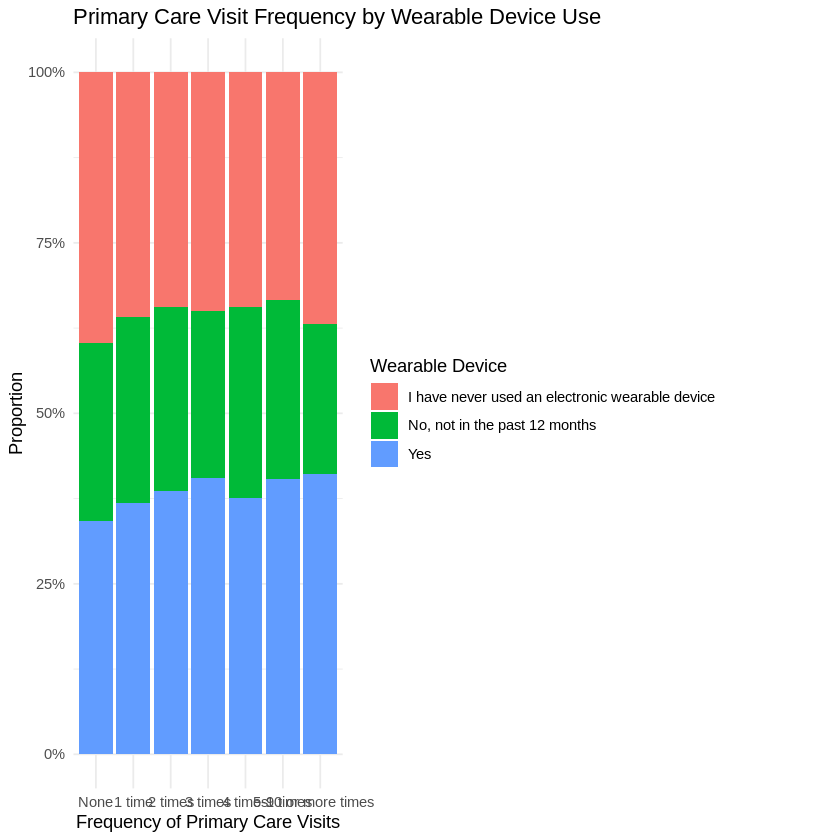

In [14]:
library(scales)
hints7_cleaned <- hints7_cleaned %>% mutate(WearableUseLabel = factor(WearableUse))
ggplot(hints7_cleaned, aes(x = FreqGoProvider, fill = WearableUseLabel)) +
  geom_bar(position = 'fill') +
  labs(title='Primary Care Visit Frequency by Wearable Device Use', x='Frequency of Primary Care Visits', y='Proportion', fill='Wearable Device') +
  theme_minimal() + scale_y_continuous(labels = scales::percent)


## Research Question 2
**How are symptoms of anxiety or depression associated with reported quality of patient-provider communication?**

In [15]:
hints7_filtered_RQ2 <- hints_df %>% dplyr::select(HHID, MedConditions_Depression, PCCScale, Age, BirthSex, RaceEthn, IncomeRanges, EducB)
bad_labels <- c('Missing Data (Not Ascertained)','Missing Data (Web partial - Question Never Seen)','Missing data (Not Ascertained)','Missing data (Web partial - Question Never Seen)','Dont know','Multiple responses selected in error','Unreadable or Nonconforming Numeric Response')
hints7_cleaned_RQ2 <- hints7_filtered_RQ2 %>% mutate(across(everything(), as.character)) %>%
  filter(!if_any(everything(), ~ .x %in% bad_labels)) %>% mutate(Age = as.numeric(Age), PCCScale = as.numeric(PCCScale)) %>% filter(Age >= 0, PCCScale >= 0)
summary(hints7_cleaned_RQ2)


     HHID           MedConditions_Depression    PCCScale           Age       
 Length:5323        Length:5323              Min.   :  0.00   Min.   : 18.0  
 Class :character   Class :character         1st Qu.: 61.90   1st Qu.: 41.0  
 Mode  :character   Mode  :character         Median : 81.00   Median : 58.0  
                                             Mean   : 76.65   Mean   : 55.5  
                                             3rd Qu.:100.00   3rd Qu.: 69.0  
                                             Max.   :100.00   Max.   :100.0  
   BirthSex           RaceEthn         IncomeRanges          EducB          
 Length:5323        Length:5323        Length:5323        Length:5323       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                     

In [16]:
vars <- c('Age','BirthSex','RaceEthn','IncomeRanges','EducB')
table1_RQ2 <- tableone::CreateTableOne(vars = vars, data = hints7_cleaned_RQ2)
print(table1_RQ2, showAllLevels = TRUE)


                  
                   level                                                 
  n                                                                      
  Age (mean (SD))                                                        
  BirthSex (%)     Female                                                
                   Male                                                  
  RaceEthn (%)     Hispanic                                              
                   Non-Hispanic American Indian or Alaska Native         
                   Non-Hispanic Asian                                    
                   Non-Hispanic Black or African American                
                   Non-Hispanic Multiple Races Mentioned                 
                   Non-Hispanic Native Hawaiian or other Pacific Islander
                   Non-Hispanic White                                    
  IncomeRanges (%) $0 to $9,999                                          
                   

In [17]:
hints7_cleaned_RQ2 <- hints7_cleaned_RQ2 %>% mutate(BirthSex=factor(BirthSex), RaceEthn=factor(RaceEthn), IncomeRanges=factor(IncomeRanges, ordered=TRUE), EducB=factor(EducB, ordered=TRUE))
model_RQ2 <- lm(PCCScale ~ MedConditions_Depression + Age + BirthSex + RaceEthn + IncomeRanges + EducB, data = hints7_cleaned_RQ2)
summary(model_RQ2)



Call:
lm(formula = PCCScale ~ MedConditions_Depression + Age + BirthSex + 
    RaceEthn + IncomeRanges + EducB, data = hints7_cleaned_RQ2)

Residuals:
    Min      1Q  Median      3Q     Max 
-80.814 -14.485   3.795  19.334  37.690 

Coefficients:
                                                               Estimate
(Intercept)                                                    67.63884
MedConditions_DepressionYes                                    -2.92133
Age                                                             0.14646
BirthSexMale                                                   -0.34952
RaceEthnNon-Hispanic American Indian or Alaska Native          -8.58422
RaceEthnNon-Hispanic Asian                                     -4.02556
RaceEthnNon-Hispanic Black or African American                  4.79734
RaceEthnNon-Hispanic Multiple Races Mentioned                  -4.21994
RaceEthnNon-Hispanic Native Hawaiian or other Pacific Islander -2.76495
RaceEthnNon-Hispanic White     

## Research Question 3
**How does exposure to online health information affect public trust in healthcare providers and systems?**

In [18]:
hints7_filtered_RQ3 <- hints_df %>% dplyr::select(HHID, Electronic2_HealthInfo, Electronic2_TestResults, TrustHCSystem, Age, BirthSex, RaceEthn, IncomeRanges, EducB)
bad_labels <- c('Missing data (Not Ascertained)','Missing Data (Not Ascertained)','Missing data (Web partial - Question Never Seen)','Question answered in error (Commission Error)','Dont know','Multiple responses selected in error','Unreadable or Nonconforming Numeric Response')
hints7_cleaned_RQ3 <- hints7_filtered_RQ3 %>% mutate(across(everything(), as.character)) %>% filter(if_all(everything(), ~ !. %in% bad_labels)) %>% mutate(Age = as.numeric(Age)) %>% filter(Age >= 0)
summary(hints7_cleaned_RQ3)


     HHID           Electronic2_HealthInfo Electronic2_TestResults
 Length:5969        Length:5969            Length:5969            
 Class :character   Class :character       Class :character       
 Mode  :character   Mode  :character       Mode  :character       
                                                                  
                                                                  
                                                                  
 TrustHCSystem           Age           BirthSex           RaceEthn        
 Length:5969        Min.   : 18.00   Length:5969        Length:5969       
 Class :character   1st Qu.: 40.00   Class :character   Class :character  
 Mode  :character   Median : 56.00   Mode  :character   Mode  :character  
                    Mean   : 54.49                                        
                    3rd Qu.: 69.00                                        
                    Max.   :102.00                                        
 Incom

In [19]:
vars <- c('Age','BirthSex','RaceEthn','IncomeRanges','EducB')
table1_RQ3 <- tableone::CreateTableOne(vars = vars, data = hints7_cleaned_RQ3)
print(table1_RQ3, showAllLevels = TRUE)


                  
                   level                                                 
  n                                                                      
  Age (mean (SD))                                                        
  BirthSex (%)     Female                                                
                   Male                                                  
  RaceEthn (%)     Hispanic                                              
                   Non-Hispanic American Indian or Alaska Native         
                   Non-Hispanic Asian                                    
                   Non-Hispanic Black or African American                
                   Non-Hispanic Multiple Races Mentioned                 
                   Non-Hispanic Native Hawaiian or other Pacific Islander
                   Non-Hispanic White                                    
  IncomeRanges (%) $0 to $9,999                                          
                   

In [20]:
hints7_cleaned_RQ3 <- hints7_cleaned_RQ3 %>% mutate(
  TrustHCSystem_binary = ifelse(TrustHCSystem == 'A lot', 1, 0),
  Electronic2_HealthInfo = factor(Electronic2_HealthInfo), Electronic2_TestResults = factor(Electronic2_TestResults),
  BirthSex = factor(BirthSex), RaceEthn = factor(RaceEthn), IncomeRanges = factor(IncomeRanges), EducB = factor(EducB)
)
model_RQ3 <- glm(TrustHCSystem_binary ~ Electronic2_HealthInfo + Electronic2_TestResults + Age + BirthSex + RaceEthn + IncomeRanges + EducB,
                 data = hints7_cleaned_RQ3, family = binomial(link = 'logit'))
summary(model_RQ3)
exp(cbind(OR = coef(model_RQ3), confint(model_RQ3)))



Call:
glm(formula = TrustHCSystem_binary ~ Electronic2_HealthInfo + 
    Electronic2_TestResults + Age + BirthSex + RaceEthn + IncomeRanges + 
    EducB, family = binomial(link = "logit"), data = hints7_cleaned_RQ3)

Coefficients: (1 not defined because of singularities)
                                                                 Estimate
(Intercept)                                                    -1.7996575
Electronic2_HealthInfoNo                                        0.1484782
Electronic2_HealthInfoYes                                       0.0270535
Electronic2_TestResultsNo                                      -0.3165210
Electronic2_TestResultsYes                                             NA
Age                                                             0.0218501
BirthSexMale                                                    0.1548780
RaceEthnNon-Hispanic American Indian or Alaska Native          -0.5296537
RaceEthnNon-Hispanic Asian                                   

Waiting for profiling to be done...



,OR,2.5 %,97.5 %
(Intercept),0.1653555,0.1044052,0.2608877
Electronic2_HealthInfoNo,1.1600675,0.8075174,1.6704643
Electronic2_HealthInfoYes,1.0274227,0.7356711,1.4390569
Electronic2_TestResultsNo,0.7286797,0.6318100,0.8394422
Electronic2_TestResultsYes,NA,NA,NA
Age,1.0220905,1.0186736,1.0255469
BirthSexMale,1.1675155,1.0442444,1.3051881
RaceEthnNon-Hispanic American Indian or Alaska Native,0.5888088,0.1591294,1.7718913
RaceEthnNon-Hispanic Asian,1.3153384,1.0126069,1.7060857
RaceEthnNon-Hispanic Black or African American,1.0003354,0.8288978,1.2068162
